# 🪙 Ethereum Account Fraud Detection
### Head-to-head comparison: Random Forest vs XGBoost — with two class-imbalance strategies

| | |
|---|---|
| **Dataset** | [Ethereum Fraud Detection Dataset](https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset) (`transaction_dataset.csv`) |
| **Task** | Binary classification of Ethereum **accounts** as fraudulent (`FLAG = 1`) or legitimate, from behavioural features of their transaction and ERC20 token history |
| **Stack** | pandas · scikit-learn · imbalanced-learn · XGBoost |
| **Models compared** | Random Forest (bagged trees) vs XGBoost (gradient-boosted trees) |
| **Imbalance strategies compared** | Random under-sampling vs SMOTE-Tomek (over-sample, then clean the boundary) |
| **Primary metric** | PR-AUC (Average Precision), backed by cost-based threshold optimisation |
| **Author** | *Your Name* |

**Design of the study**
- 🔒 **Leakage-safe** — the holdout is carved out *before* EDA; imputation, one-hot encoding and resampling all live inside the CV folds.
- ⚖️ **2 imbalance strategies × 2 models** — four configurations compared under identical stratified CV.
- 🤖 **2 models** — each model is carried forward with whichever imbalance strategy scored best for it.
- 💰 **Business decisioning** — cost-optimal thresholds, alert-budget recall, gains/lift and calibration.
- 📊 **Statistical check** — a paired bootstrap on the holdout shows whether the gap between the two models is real.
- 🔍 **Interpretability** — permutation importance on the holdout compares what each model relies on.

## 📑 Table of Contents
1. [Problem Statement](#1)
2. [Environment Setup & Configuration](#2)
3. [Data Acquisition (Kaggle → Python)](#3)
4. [Data Audit & Quality Checks](#4)
5. [Preprocessing & Feature Engineering](#5)
6. [Exploratory Data Analysis](#6)
7. [Modelling Framework](#7)
8. [Class Imbalance: Under-sampling vs SMOTE-Tomek](#8)
9. [Model Comparison: Random Forest vs XGBoost](#9)
10. [Holdout Evaluation & Business Decisioning](#10)
11. [Conclusions](#11)

<a id="1"></a>
## 1. Problem Statement

### 1.1 Business context
Ethereum is permissionless: anyone can open an account in seconds, which makes it a favourite channel for phishing, Ponzi schemes, rug-pulls and laundering. Exchanges, wallets and compliance teams must decide **which accounts to block, freeze or manually investigate**. Investigators are scarce and every false alarm freezes an honest user's funds, so accounts need to be *ranked by fraud risk*.

### 1.2 Objective
Build a model that scores every Ethereum account with a **fraud probability** so that:
1. the compliance team reviews accounts in order of risk and catches as much fraud as possible within its capacity, and
2. the flag / no-flag decision minimises the **expected cost** of missed fraud plus investigation effort.

### 1.3 ML framing
| Item | Definition |
|---|---|
| Unit of analysis | One Ethereum account (one row per address) |
| Target | `FLAG` (1 = account labelled fraudulent) |
| Features | Account behaviour: transaction counts and timing, Ether sent / received, contract interaction, ERC20 token activity and the most-used token types |
| Type | Supervised binary classification, moderately imbalanced (fraud is the minority class) |

### 1.4 Success metrics
- **PR-AUC (Average Precision)** — primary model-selection metric; it directly reflects how clean the alert queue is.
- **Recall at the alert budget** — share of all fraud captured if only the top-ranked *k%* of accounts can be reviewed.
- **Expected cost** — `FN × cost_missed_fraud + FP × cost_investigation`, used to set the operating threshold.
- **ROC-AUC, F2, calibration (Brier)** — supporting diagnostics. F2 weights recall above precision.

### 1.5 Key challenges
- **Heavy-tailed features** — Ether values and counts span many orders of magnitude (a few whales dominate); tree models are robust to this, but it shapes EDA.
- **Redundant and constant columns** — dozens of ERC20 aggregates are highly correlated and some are constant.
- **Missing values** — ERC20 columns are blank for accounts that never touched a token.
- **High-cardinality categorical columns** — the most-sent / most-received ERC20 token names.
- **Account-level snapshot** — there is no time variable, so out-of-time validation is not possible; a random stratified split is the best available estimate.

<a id="2"></a>
## 2. Environment Setup & Configuration
Uncomment the install line on a fresh environment (Colab, Kaggle, local venv).

In [1]:
# !pip install -q kagglehub kaggle imbalanced-learn xgboost seaborn

In [2]:
import os, json, time, random, shutil, zipfile, warnings, platform, re
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay, fbeta_score, brier_score_loss)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

In [3]:
@dataclass
class Config:
    dataset: str = "vagifa/ethereum-frauddetection-dataset"
    csv_name: str = "transaction_dataset.csv"
    data_dir: Path = Path("data")
    target: str = "flag"                # column names are normalised to snake_case in Section 4
    seed: int = 42
    test_size: float = 0.20
    n_folds: int = 5
    n_bootstrap: int = 1000
    n_perm_repeats: int = 10
    corr_threshold: float = 0.95        # Spearman |rho| above which a numeric feature is treated as redundant
    # --- Business cost assumptions (ILLUSTRATIVE — tune with the compliance team) ---
    cost_missed_fraud: float = 2000.0   # avg. loss when a fraudulent account is not flagged (FN)
    cost_investigation: float = 100.0   # avg. analyst cost of reviewing a legitimate account (FP)
    alert_budget: float = 0.20          # review capacity: share of accounts that can be investigated
    quick_run: bool = False             # smoke-test mode for CI

CFG = Config()
if os.environ.get("QUICK_RUN") == "1":           # e.g. QUICK_RUN=1 jupyter nbconvert --execute ...
    CFG.quick_run, CFG.n_folds, CFG.n_bootstrap, CFG.n_perm_repeats = True, 3, 200, 3

CFG.data_dir.mkdir(exist_ok=True, parents=True)
TARGET, SEED = CFG.target, CFG.seed

def seed_everything(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
seed_everything(SEED)

# ---- Visual identity ----
PALETTE = {"legit": "#2E86AB", "fraud": "#E63946", "accent": "#F4A261", "dark": "#1D3557", "muted": "#A8DADC"}
MODEL_COLOR = {"Random Forest": "#2A9D8F", "XGBoost": "#E76F51"}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.titlepad": 10})

print(f"Python {platform.python_version()} | pandas {pd.__version__} | sklearn {__import__('sklearn').__version__} | "
      f"xgboost {xgb.__version__}")
print("Config:", {k: str(v) for k, v in asdict(CFG).items()})

Python 3.13.15 | pandas 2.2.3 | sklearn 1.6.1 | xgboost 3.4.1
Config: {'dataset': 'vagifa/ethereum-frauddetection-dataset', 'csv_name': 'transaction_dataset.csv', 'data_dir': 'data', 'target': 'flag', 'seed': '42', 'test_size': '0.2', 'n_folds': '5', 'n_bootstrap': '1000', 'n_perm_repeats': '10', 'corr_threshold': '0.95', 'cost_missed_fraud': '2000.0', 'cost_investigation': '100.0', 'alert_budget': '0.2', 'quick_run': 'False'}


<a id="3"></a>
## 3. Data Acquisition (Kaggle → Python)

The dataset is pulled **programmatically** with a layered fallback so the notebook runs anywhere:

| Priority | Method | Requirement |
|---|---|---|
| 0 | Re-use an already extracted `transaction_dataset.csv` in `./data` | none (cached) |
| 1 | `kagglehub.dataset_download()` | Kaggle credentials for most setups |
| 2 | Official Kaggle API → download `.zip` → extract with `zipfile` | `~/.kaggle/kaggle.json` or `KAGGLE_USERNAME` / `KAGGLE_KEY` |
| 3 | Extract any manually downloaded `.zip` placed in `./data` | the zip file |

> 🔑 **Credentials:** Kaggle → *Settings* → *API* → *Create New Token*. Put `kaggle.json` in `~/.kaggle/` (chmod 600) or set the two environment variables. **Never hard-code keys in a notebook.**

In [5]:
def _extract_zips(folder: Path):
    """Extract every zip archive in `folder` (idempotent)."""
    for zp in folder.glob("*.zip"):
        with zipfile.ZipFile(zp) as zf:
            print(f"  ↳ extracting {zp.name}: {zf.namelist()}")
            zf.extractall(folder)

def fetch_dataset(cfg: Config = CFG) -> Path:
    target_csv = cfg.data_dir / cfg.csv_name

    # 0) Cached / manually downloaded
    _extract_zips(cfg.data_dir)
    hits = list(cfg.data_dir.rglob(cfg.csv_name))
    if hits:
        print(f"Using cached file: {hits[0]}")
        return hits[0]

    # 1) kagglehub
    try:
        import kagglehub
        print("Trying kagglehub ...")
        cache_path = Path(kagglehub.dataset_download(cfg.dataset))
        _extract_zips(cache_path)
        src = next(cache_path.rglob(cfg.csv_name))
        shutil.copy(src, target_csv)
        print(f"Downloaded via kagglehub → {target_csv}")
        return target_csv
    except Exception as e:
        print(f"   kagglehub unavailable/failed: {type(e).__name__}: {e}")

    # 2) Official Kaggle API
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        print("Trying official Kaggle API ...")
        api = KaggleApi(); api.authenticate()
        api.dataset_download_files(cfg.dataset, path=str(cfg.data_dir), unzip=False, quiet=False)
        _extract_zips(cfg.data_dir)
        src = next(cfg.data_dir.rglob(cfg.csv_name))
        print(f"Downloaded via Kaggle API → {src}")
        return src
    except Exception as e:
        print(f"   Kaggle API unavailable/failed: {type(e).__name__}: {e}")

    raise RuntimeError(
        "Could not obtain the dataset automatically.\n"
        "Configure Kaggle credentials (see markdown above), or download the zip from\n"
        f"https://www.kaggle.com/datasets/{cfg.dataset} and place it in '{cfg.data_dir.resolve()}'.")

CSV_PATH = fetch_dataset()
df_raw = pd.read_csv(CSV_PATH)
print(f"\nLoaded {CSV_PATH.name}: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns ({CSV_PATH.stat().st_size/1e6:.2f} MB)")
df_raw.head()

Using cached file: data/transaction_dataset.csv

Loaded transaction_dataset.csv: 9,841 rows × 51 columns (2.88 MB)


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.00,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.00,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.05,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.00,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.00,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


<a id="4"></a>
## 4. Data Audit & Quality Checks
The raw headers are inconsistent (leading spaces, mixed case, `ERC20_most_rec_token_type` vs `ERC20 most sent token type`). We first **normalise every column name to snake_case**, then profile each column: type, cardinality, missingness and representative values.

In [6]:
def normalise(name: str) -> str:
    return re.sub(r"[^0-9a-z]+", "_", str(name).strip().lower()).strip("_")

df_audit = df_raw.copy()
df_audit.columns = [normalise(c) for c in df_audit.columns]
assert TARGET in df_audit.columns, f"Target '{TARGET}' not found. Columns: {list(df_audit.columns)}"

def audit(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "sample_values": [list(map(str, df[c].dropna().unique()[:4])) for c in df.columns],
    })

audit_df = audit(df_audit)
display(audit_df)
print(f"Numeric cols: {df_audit.select_dtypes('number').shape[1]} | Text cols: {df_audit.select_dtypes(exclude='number').shape[1]}")

,dtype,n_unique,missing,missing_%,sample_values
unnamed_0,int64,9841,0,0.00,"[0, 1, 2, 3]"
index,int64,4729,0,0.00,"[1, 2, 3, 4]"
address,object,9816,0,0.00,"[0x00009277775ac7d0d59eaad8fee3d10ac6c805e8, 0..."
flag,int64,2,0,0.00,"[0, 1]"
avg_min_between_sent_tnx,float64,5013,0,0.00,"[844.26, 12709.07, 246194.54, 10219.6]"
avg_min_between_received_tnx,float64,6223,0,0.00,"[1093.71, 2958.44, 2434.02, 15785.09]"
time_diff_between_first_and_last_mins,float64,7810,0,0.00,"[704785.63, 1218216.73, 516729.3, 397555.9]"
sent_tnx,int64,641,0,0.00,"[721, 94, 2, 25]"
received_tnx,int64,727,0,0.00,"[89, 8, 10, 9]"
number_of_created_contracts,int64,20,0,0.00,"[0, 1, 3, 2]"


Numeric cols: 48 | Text cols: 3


,value
Fully duplicated rows (all columns),0
Duplicated rows ignoring ID columns,18
Duplicated addresses (should be unique),25
Rows with any missing value,2720
Columns with any missing value,25
Constant columns (no information),0 → []
Text (categorical) feature columns,"['erc20_most_sent_token_type', 'erc20_most_rec..."
Fraud rate,"22.14% (2,179 of 9,841)"


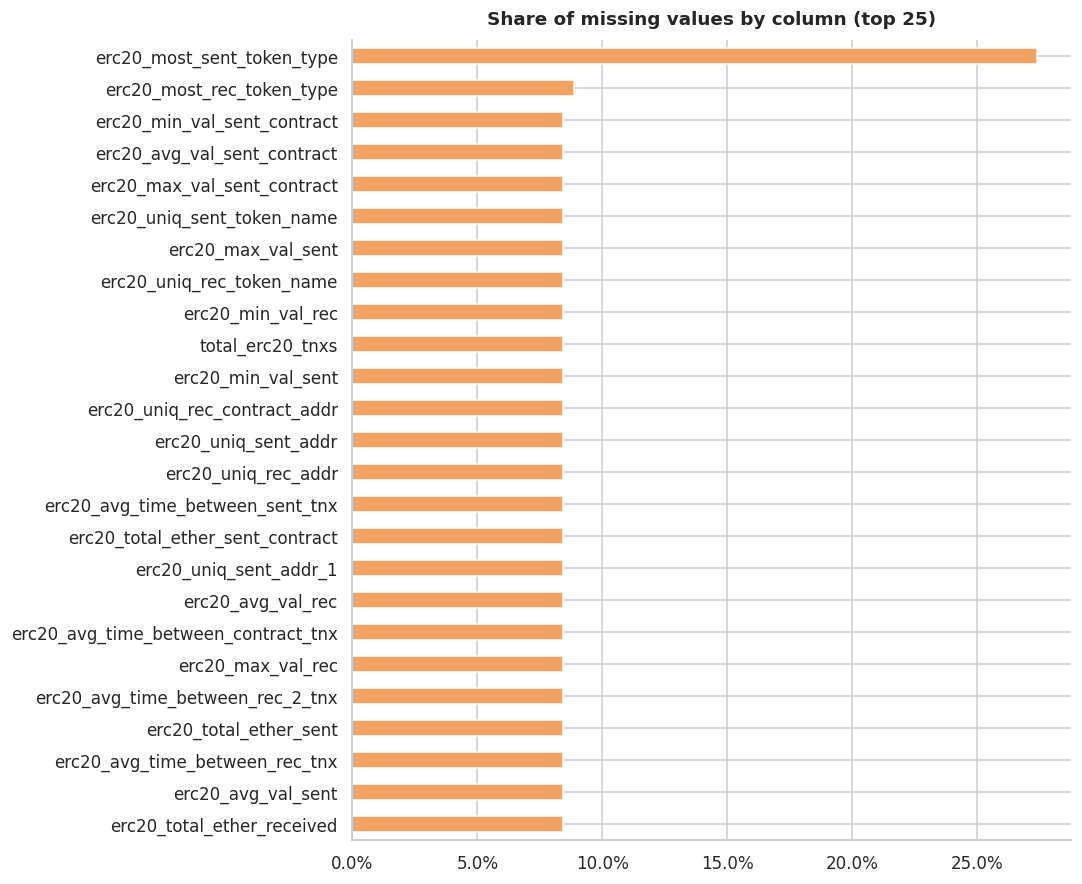

In [7]:
id_like = [c for c in ["unnamed_0", "index", "address"] if c in df_audit.columns]
feature_cols_raw = [c for c in df_audit.columns if c not in id_like + [TARGET]]
constant_cols = [c for c in feature_cols_raw if df_audit[c].nunique(dropna=False) <= 1]

checks = {
    "Fully duplicated rows (all columns)": int(df_audit.duplicated().sum()),
    "Duplicated rows ignoring ID columns": int(df_audit.drop(columns=[c for c in ["unnamed_0", "index"] if c in df_audit]).duplicated().sum()),
    "Duplicated addresses (should be unique)": int(df_audit["address"].duplicated().sum()) if "address" in df_audit else "n/a",
    "Rows with any missing value": int(df_audit.isna().any(axis=1).sum()),
    "Columns with any missing value": int(df_audit.isna().any().sum()),
    "Constant columns (no information)": f"{len(constant_cols)} → {constant_cols}",
    "Text (categorical) feature columns": f"{[c for c in feature_cols_raw if not pd.api.types.is_numeric_dtype(df_audit[c])]}",
    "Fraud rate": f"{df_audit[TARGET].mean():.2%}  ({int(df_audit[TARGET].sum()):,} of {len(df_audit):,})",
}
display(pd.Series(checks, name="value").to_frame())

miss = df_audit.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss):
    fig, ax = plt.subplots(figsize=(10, 0.28 * min(len(miss), 25) + 1.2))
    miss.head(25).sort_values().plot.barh(color=PALETTE["accent"], ax=ax)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_title("Share of missing values by column (top 25)")
    plt.tight_layout(); plt.show()

**Audit findings → preprocessing decisions**

| Finding | Decision |
|---|---|
| `Unnamed: 0`, `Index` and `Address` are identifiers | Drop (no behavioural meaning; a memorisation risk) |
| Constant columns carry no information | Drop (label-free, so safe to decide on the full data) |
| Exact duplicate account rows | Drop, keeping the first occurrence, so the same account cannot sit in both train and holdout |
| Missing values in ERC20 columns (account never touched a token) | Median imputation **inside the pipeline** plus missing-indicator flags — missingness itself can be a signal |
| Two text columns: most-sent / most-received token type | Rare levels grouped, then one-hot encoded inside the pipeline |
| Many highly correlated numeric columns | Drop redundant ones using the **training set only** (Spearman |ρ| above the configured threshold) |
| Heavy-tailed numeric features | Keep as-is — tree ensembles are invariant to monotone transforms; use signed-log only for plotting |

<a id="5"></a>
## 5. Preprocessing & Feature Engineering
Everything in `clean()` and `engineer()` is **deterministic and row-level** (no statistics learned from data), so applying it before the split cannot leak information. Anything *learned* (imputation values, one-hot levels, resampling, correlation pruning) is fitted on training data only.

In [8]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    """Normalise names, drop identifiers / constant columns / duplicate accounts, tidy text columns."""
    df = df.copy()
    df.columns = [normalise(c) for c in df.columns]
    ids = [c for c in ["unnamed_0", "index"] if c in df.columns]
    n0 = len(df)
    df = df.drop_duplicates(subset=[c for c in df.columns if c not in ids]).copy()
    if "address" in df.columns:
        df = df.drop_duplicates(subset=["address"]).copy()
    const = [c for c in df.columns if c not in ids + ["address", TARGET] and df[c].nunique(dropna=False) <= 1]
    df = df.drop(columns=ids + ["address"] + const, errors="ignore")
    for c in df.select_dtypes(exclude="number").columns:
        df[c] = df[c].fillna("missing").astype(str).str.strip().replace({"nan": "missing", "": "missing", "None": "missing"})
    df[TARGET] = df[TARGET].astype(int)
    print(f"clean(): removed {n0 - len(df)} duplicate rows and {len(const)} constant columns → {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df.reset_index(drop=True)

def pick(df, *patterns):
    """First column whose normalised name matches any regex pattern (None if absent) — keeps engineering robust to header quirks."""
    for p in patterns:
        for c in df.columns:
            if re.fullmatch(p, c):
                return c
    return None

def engineer(df: pd.DataFrame) -> pd.DataFrame:
    """Domain-driven ratios describing the shape of an account's behaviour."""
    df = df.copy()
    eps = 1e-9
    sent, rec = pick(df, r"sent_tnx"), pick(df, r"received_tnx")
    eth_s, eth_r = pick(df, r"total_ether_sent"), pick(df, r"total_ether_received")
    bal = pick(df, r"total_ether_balance")
    uniq_to, uniq_from = pick(df, r"unique_sent_to_addresses"), pick(df, r"unique_received_from_addresses")
    span = pick(df, r"time_diff_between_first_and_last_mins")
    if sent and rec:
        df["tx_total"] = df[sent] + df[rec]
        df["tx_sent_share"] = df[sent] / (df["tx_total"] + eps)
    if eth_s and eth_r:
        df["eth_net_flow"] = df[eth_r] - df[eth_s]
        df["eth_sent_share"] = df[eth_s] / (df[eth_s] + df[eth_r] + eps)
    if eth_s and sent:
        df["eth_per_sent_tx"] = df[eth_s] / (df[sent] + 1)
    if eth_r and rec:
        df["eth_per_received_tx"] = df[eth_r] / (df[rec] + 1)
    if bal and eth_r:
        df["balance_to_received"] = df[bal] / (df[eth_r] + eps)
    if uniq_to and sent:
        df["sent_counterparty_diversity"] = df[uniq_to] / (df[sent] + 1)
    if uniq_from and rec:
        df["received_counterparty_diversity"] = df[uniq_from] / (df[rec] + 1)
    if span and "tx_total" in df:
        df["tx_per_day"] = df["tx_total"] / (df[span] / 1440 + 1)
    return df.replace([np.inf, -np.inf], np.nan)

df = engineer(clean(df_raw))
ENGINEERED = [c for c in ["tx_total", "tx_sent_share", "eth_net_flow", "eth_sent_share", "eth_per_sent_tx", "eth_per_received_tx",
                          "balance_to_received", "sent_counterparty_diversity", "received_counterparty_diversity", "tx_per_day"] if c in df.columns]
NOMINAL = [c for c in df.columns if c != TARGET and not pd.api.types.is_numeric_dtype(df[c])]   # object or pandas "str" dtype
NUMERIC_ALL = [c for c in df.columns if c != TARGET and c not in NOMINAL]
print(f"{len(NOMINAL)} nominal {NOMINAL} | {len(NUMERIC_ALL)} numeric (of which {len(ENGINEERED)} engineered: {ENGINEERED})")

clean(): removed 25 duplicate rows and 0 constant columns → 9,816 rows × 48 columns
2 nominal ['erc20_most_sent_token_type', 'erc20_most_rec_token_type'] | 55 numeric (of which 10 engineered: ['tx_total', 'tx_sent_share', 'eth_net_flow', 'eth_sent_share', 'eth_per_sent_tx', 'eth_per_received_tx', 'balance_to_received', 'sent_counterparty_diversity', 'received_counterparty_diversity', 'tx_per_day'])


### 5.1 Train / holdout split — *before* EDA
A stratified **20% holdout** is locked away now. All EDA, correlation pruning, sampling experiments and threshold selection use the training set only; the holdout is touched exactly once, in Section 10, to give an unbiased estimate of real-world performance.

In [9]:
train_df, test_df = train_test_split(df, test_size=CFG.test_size, stratify=df[TARGET], random_state=SEED)
train_df, test_df = train_df.reset_index(drop=True), test_df.reset_index(drop=True)

# Redundancy pruning learned on the TRAINING set only (label-free)
rho = train_df[NUMERIC_ALL].corr(method="spearman").abs()
upper = rho.where(np.triu(np.ones(rho.shape, dtype=bool), k=1))
DROP_CORR = [c for c in upper.columns if (upper[c] > CFG.corr_threshold).any()]
NUMERIC = [c for c in NUMERIC_ALL if c not in DROP_CORR]
FEATURES = NOMINAL + NUMERIC
print(f"Correlation pruning (|Spearman| > {CFG.corr_threshold}): dropped {len(DROP_CORR)} redundant numeric columns → {len(NUMERIC)} numeric kept")

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]
display(pd.DataFrame({
    "rows": [len(train_df), len(test_df)],
    "frauds": [int(y_train.sum()), int(y_test.sum())],
    "fraud_rate": [f"{y_train.mean():.2%}", f"{y_test.mean():.2%}"]}, index=["train", "holdout"]))
print(f"Legit : fraud ratio in train = {(y_train == 0).sum() / (y_train == 1).sum():.1f} : 1 | model features: {len(FEATURES)}")

Correlation pruning (|Spearman| > 0.95): dropped 19 redundant numeric columns → 36 numeric kept


,rows,frauds,fraud_rate
train,7852,1743,22.20%
holdout,1964,436,22.20%


Legit : fraud ratio in train = 3.5 : 1 | model features: 38


<a id="6"></a>
## 6. Exploratory Data Analysis
*(training set only)*
### 6.1 Target distribution

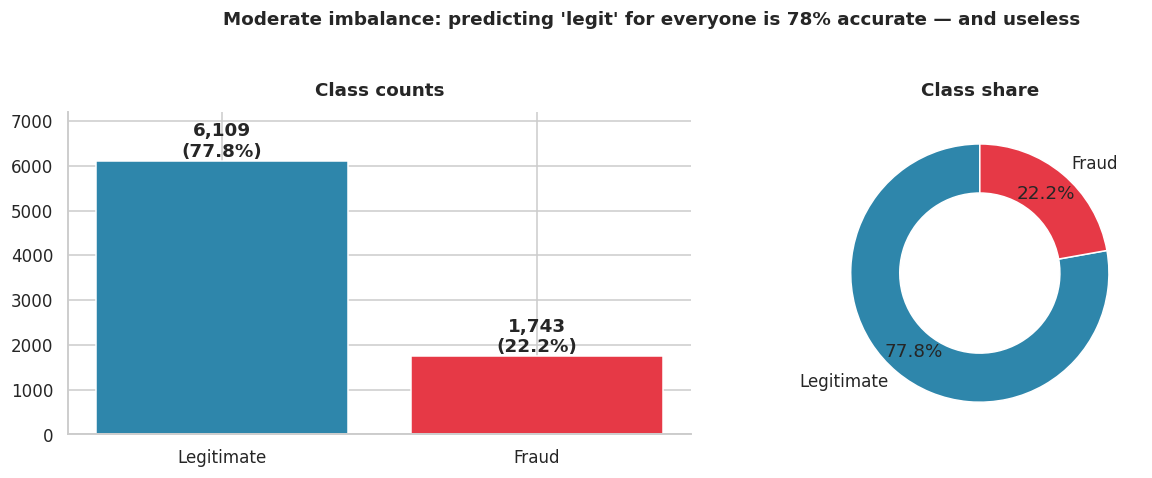

In [10]:
eda = train_df.copy()
OVERALL = eda[TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
counts = eda[TARGET].value_counts().sort_index()
axes[0].bar(["Legitimate", "Fraud"], counts.values, color=[PALETTE["legit"], PALETTE["fraud"]], edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}\n({v/counts.sum():.1%})", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Class counts"); axes[0].set_ylim(0, counts.max() * 1.18)
axes[1].pie(counts.values, labels=["Legitimate", "Fraud"], colors=[PALETTE["legit"], PALETTE["fraud"]],
            autopct="%1.1f%%", startangle=90, wedgeprops=dict(width=0.38, edgecolor="white"), pctdistance=0.8)
axes[1].set_title("Class share")
fig.suptitle(f"Moderate imbalance: predicting 'legit' for everyone is {1-OVERALL:.0%} accurate — and useless",
             fontsize=12, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

### 6.2 What separates fraud from legitimate accounts?
Mutual information ranks features by how much each one alone tells us about the label (computed on imputed training data). The distributions of the top features are then plotted on a **signed-log scale** because the raw values are extremely heavy-tailed.

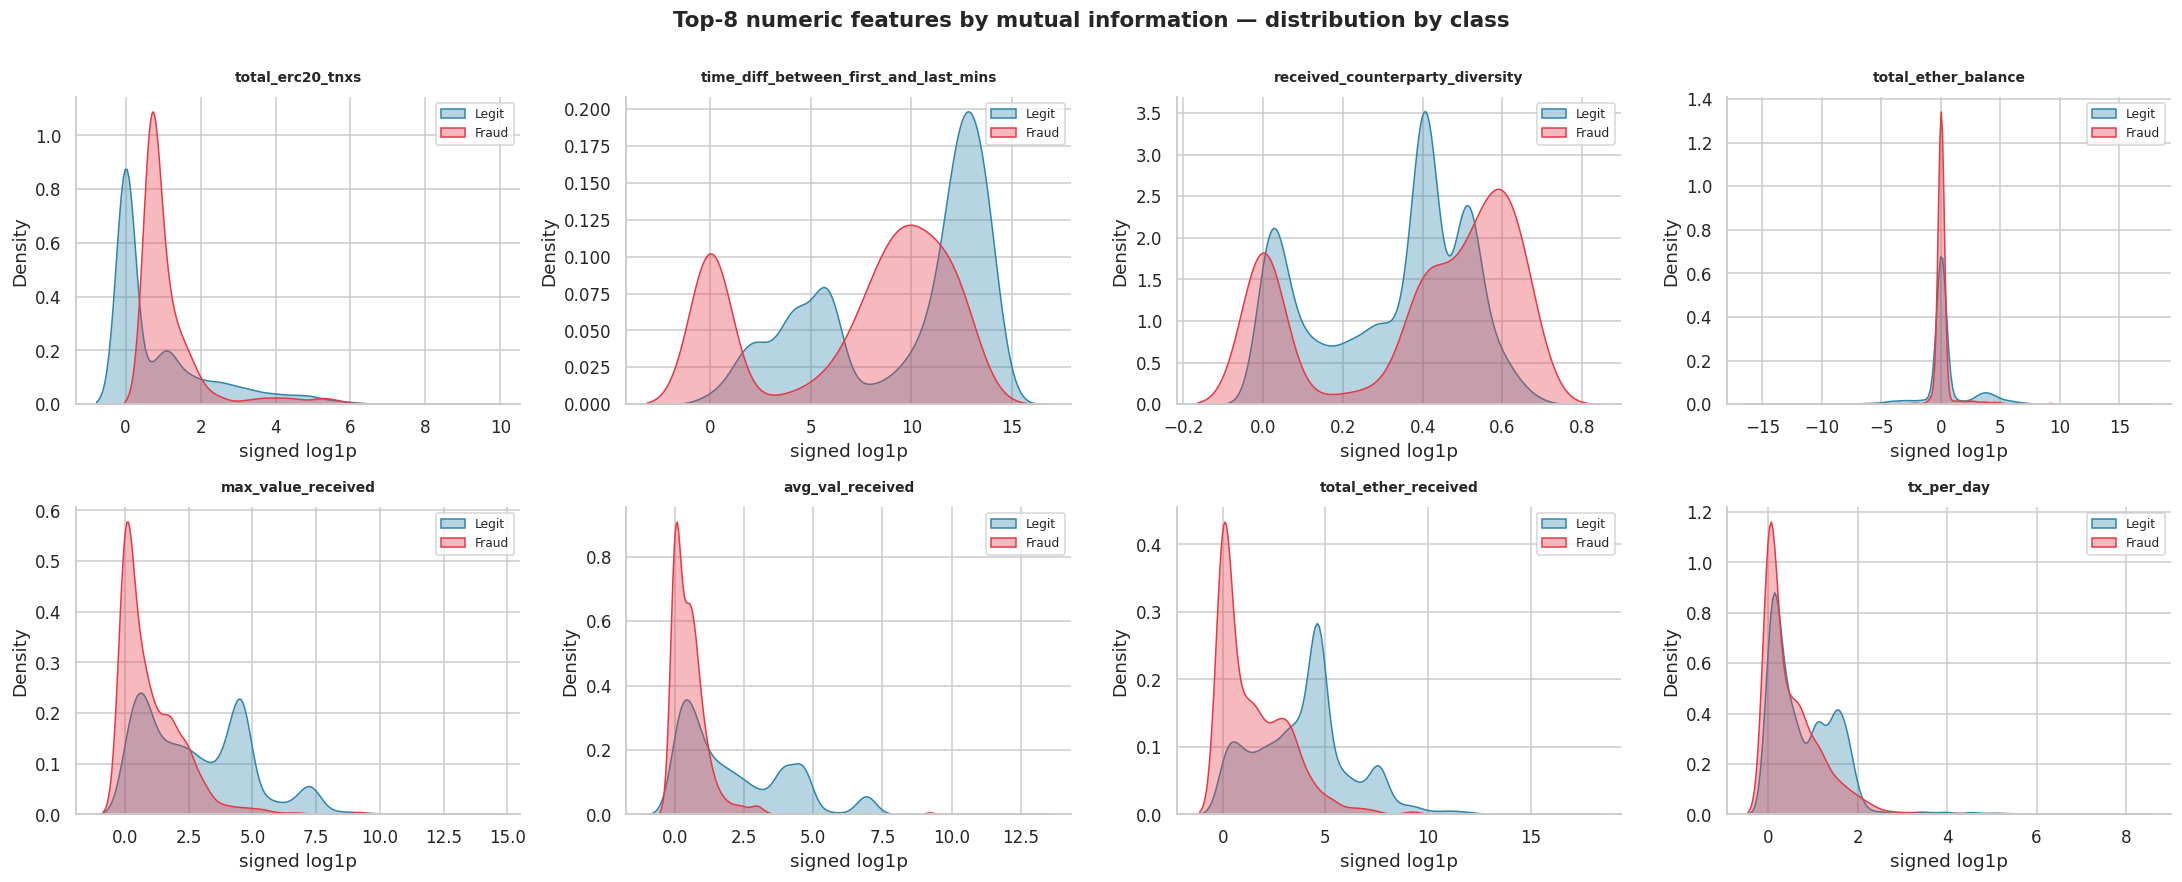

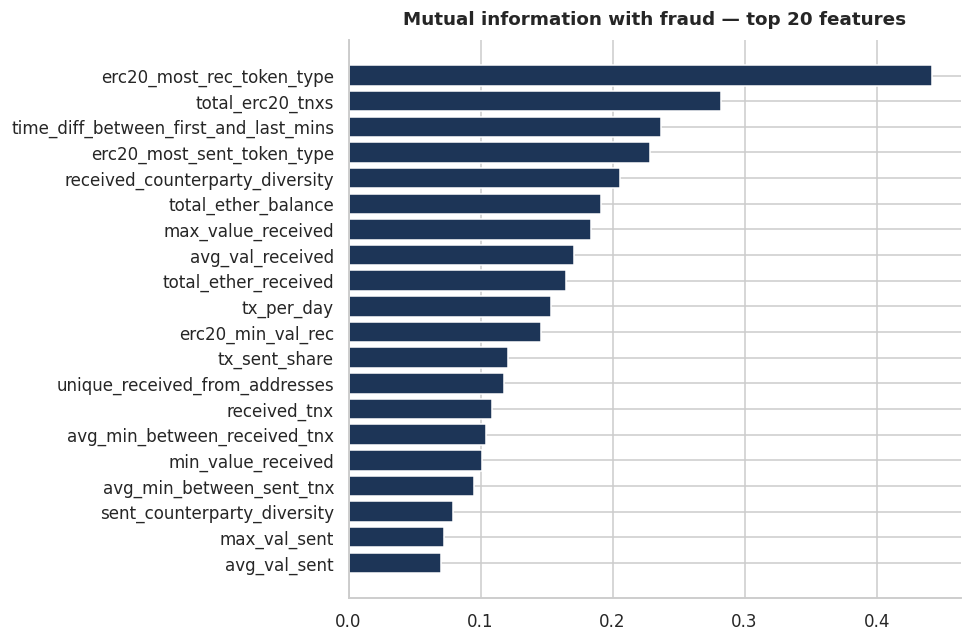

In [11]:
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_mi = X_train[NUMERIC].fillna(X_train[NUMERIC].median()).astype(float)
if NOMINAL:
    X_nom = pd.DataFrame(enc.fit_transform(X_train[NOMINAL]), columns=NOMINAL, index=X_train.index).astype(float)
    X_mi = pd.concat([X_nom, X_mi], axis=1)
X_mi = X_mi[FEATURES]
discrete = [c in NOMINAL for c in X_mi.columns]
mi = pd.Series(mutual_info_classif(X_mi, y_train, discrete_features=discrete, random_state=SEED),
               index=X_mi.columns, name="Mutual information").sort_values(ascending=False)

def slog(x): return np.sign(x) * np.log1p(np.abs(x))

top_feats = [c for c in mi.index if c in NUMERIC][:8]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, c in zip(axes.ravel(), top_feats):
    for lbl, color, name in [(0, PALETTE["legit"], "Legit"), (1, PALETTE["fraud"], "Fraud")]:
        sns.kdeplot(slog(eda.loc[eda[TARGET] == lbl, c].dropna()), fill=True, alpha=0.35, color=color, ax=ax, label=name, warn_singular=False)
    ax.set_title(c, fontsize=9); ax.set_xlabel("signed log1p"); ax.legend(fontsize=8)
fig.suptitle("Top-8 numeric features by mutual information — distribution by class", fontsize=14, fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
top_mi = mi.head(20).sort_values()
ax.barh(top_mi.index, top_mi.values, color=PALETTE["dark"]); ax.set_title("Mutual information with fraud — top 20 features")
plt.tight_layout(); plt.show()

### 6.3 Token types and redundancy structure

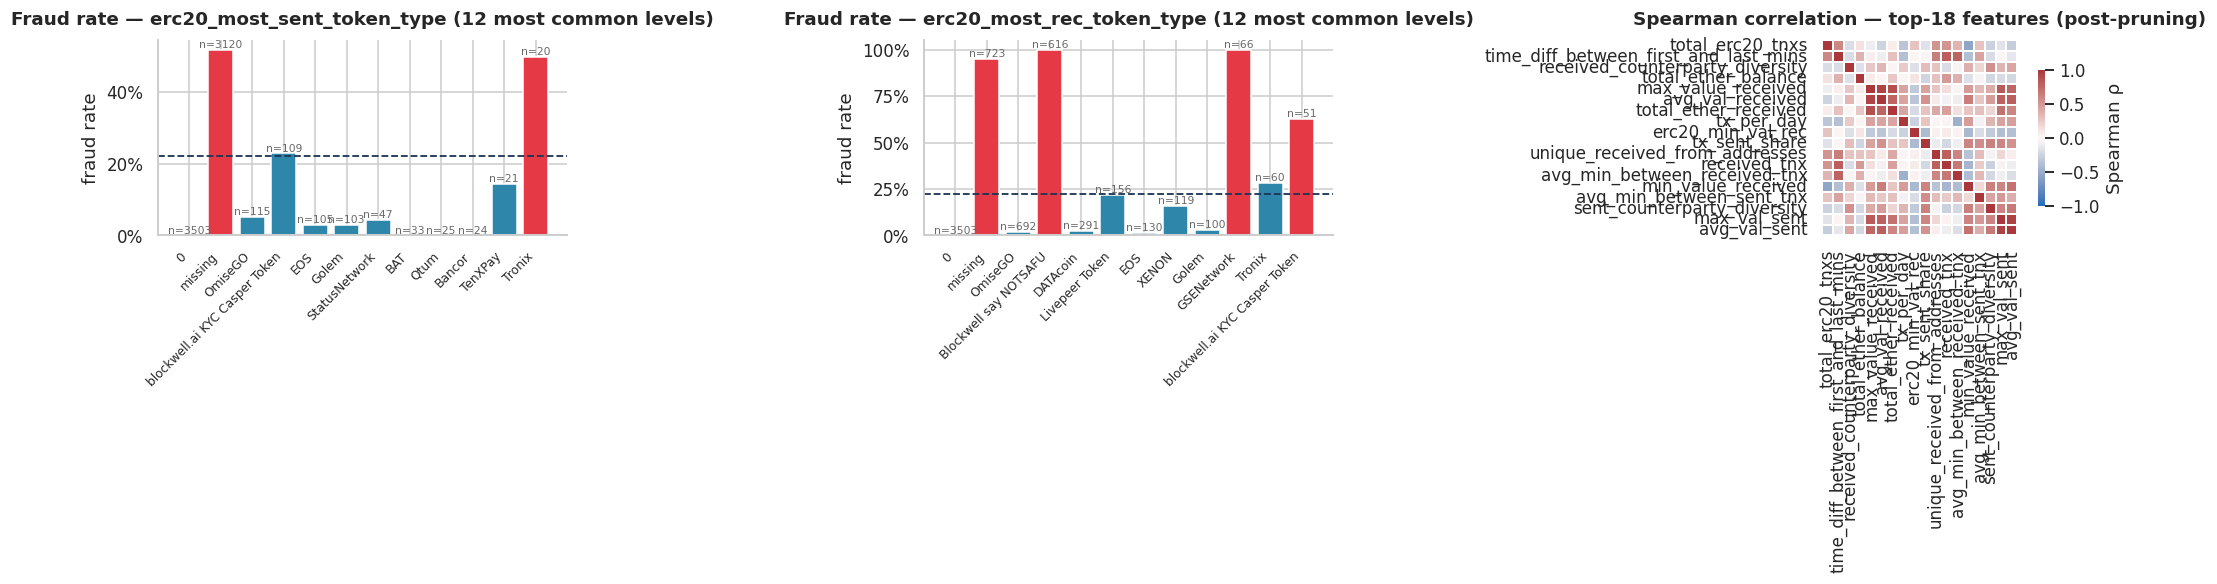

In [12]:
fig, axes = plt.subplots(1, 1 + len(NOMINAL), figsize=(7 + 6 * len(NOMINAL), 5.2))
axes = np.atleast_1d(axes)

# Fraud rate by token type (top levels by volume)
for ax, col in zip(axes[:len(NOMINAL)], NOMINAL):
    g = eda.groupby(col)[TARGET].agg(rate="mean", n="size").sort_values("n", ascending=False).head(12)
    colors = [PALETTE["fraud"] if r >= 1.5 * OVERALL else PALETTE["legit"] for r in g["rate"]]
    ax.bar(g.index.astype(str), g["rate"], color=colors, edgecolor="white")
    ax.axhline(OVERALL, ls="--", lw=1.2, color=PALETTE["dark"])
    for i, (r, n) in enumerate(zip(g["rate"], g["n"])):
        ax.text(i, r, f"n={n}", ha="center", va="bottom", fontsize=7, color="dimgray")
    ax.set_title(f"Fraud rate — {col} (12 most common levels)"); ax.set_ylabel("fraud rate")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax.tick_params(axis="x", rotation=45, labelsize=8)
    for lbl in ax.get_xticklabels(): lbl.set_ha("right")

# Correlation among the most informative numeric features (after pruning)
cols = [c for c in mi.index if c in NUMERIC][:18]
sns.heatmap(eda[cols].corr(method="spearman"), cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.7, "label": "Spearman ρ"}, ax=axes[-1])
axes[-1].set_title("Spearman correlation — top-18 features (post-pruning)")
plt.tight_layout(); plt.show()

### 6.4 EDA takeaways
Read the charts above alongside these interpretation notes (the exact numbers are printed by the cells):

1. **Imbalance is moderate, not extreme** → accuracy is still misleading; use PR-AUC, recall at a fixed review budget and cost.
2. **Behavioural signals dominate.** Transaction timing, counterparty diversity and the shape of Ether flows carry the strongest univariate signal — fraudulent accounts tend to behave *differently in rhythm and structure*, not just in size.
3. **Heavy tails everywhere** → means are dominated by a few whales; tree ensembles are invariant to monotone transforms, so no scaling is needed.
4. **Token-type columns are sparse** → rare levels are grouped, and the missing-indicator flags added by the imputer let the models exploit "never used ERC20" patterns.
5. **Redundancy was substantial** → correlation pruning on the training set shrinks the feature space without touching the label.

<a id="7"></a>
## 7. Modelling Framework
- **Preprocessing** — median imputation (+ missing indicators) for numeric features; one-hot encoding with rare-level grouping (`min_frequency=20`) for token types. No scaling: both models are tree-based.
- **Validation** — stratified K-fold on the training set produces **out-of-fold (OOF) predictions**, used for model selection *and* threshold selection. The holdout stays untouched.
- **Helpers** — metric and threshold utilities shared by every model.

In [13]:
def make_preprocessor() -> ColumnTransformer:
    transformers = [("num", SimpleImputer(strategy="median", add_indicator=True), NUMERIC)]
    if NOMINAL:
        transformers.insert(0, ("nom", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20, sparse_output=False), NOMINAL))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)

def build_pipeline(model, sampler=None) -> ImbPipeline:
    steps = [("prep", make_preprocessor())]
    if sampler is not None:
        steps.append(("sampler", clone(sampler)))      # resampling happens ONLY on the training fold
    steps.append(("clf", model))
    return ImbPipeline(steps)

CV = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=SEED)

def recall_at_k(y, p, k=CFG.alert_budget) -> float:
    y = np.asarray(y); n = max(1, int(np.ceil(k * len(p))))
    return float(y[np.argsort(-np.asarray(p))[:n]].sum() / max(y.sum(), 1))

def expected_cost(y, p, thr, c_fn=CFG.cost_missed_fraud, c_fp=CFG.cost_investigation) -> float:
    y = np.asarray(y); pred = np.asarray(p) >= thr
    return float(((~pred) & (y == 1)).sum() * c_fn + (pred & (y == 0)).sum() * c_fp)

def best_threshold(y, p) -> float:
    grid = np.unique(np.quantile(p, np.linspace(0, 0.999, 400)))     # score-scale agnostic
    costs = [expected_cost(y, p, t) for t in grid]
    return float(grid[int(np.argmin(costs))])

def evaluate(y, p, thr, name) -> dict:
    y = np.asarray(y); pred = (np.asarray(p) >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    cost, no_model_cost = expected_cost(y, p, thr), y.sum() * CFG.cost_missed_fraud
    return {"model": name, "PR-AUC": average_precision_score(y, p), "ROC-AUC": roc_auc_score(y, p),
            f"Recall@{CFG.alert_budget:.0%}": recall_at_k(y, p), "threshold": thr,
            "precision": tp / max(tp + fp, 1), "recall": tp / max(tp + fn, 1),
            "F2": fbeta_score(y, pred, beta=2, zero_division=0), "alert_rate": pred.mean(),
            "TP": tp, "FP": fp, "FN": fn, "exp_cost": cost, "savings_vs_no_model": 1 - cost / no_model_cost}

K = f"Recall@{CFG.alert_budget:.0%}"
print(f"CV: {CFG.n_folds}-fold stratified | cost FN = {CFG.cost_missed_fraud:,.0f}, FP = {CFG.cost_investigation:,.0f} "
      f"→ break-even fraud probability ≈ {CFG.cost_investigation/(CFG.cost_investigation+CFG.cost_missed_fraud):.1%} (illustrative costs)")

CV: 5-fold stratified | cost FN = 2,000, FP = 100 → break-even fraud probability ≈ 4.8% (illustrative costs)


<a id="8"></a>
## 8. Class Imbalance: Under-sampling vs SMOTE-Tomek
We compare two data-level remedies, each on both models, under identical stratified CV:

| Strategy | Idea | Trade-off |
|---|---|---|
| **Random under-sampling** | Discard random legitimate accounts until the classes are balanced | Fast and unbiased towards synthetic artefacts, but throws away information |
| **SMOTE-Tomek** | Create synthetic frauds by interpolating between fraud neighbours (SMOTE), then remove borderline majority/minority pairs (Tomek links) | Keeps all real data and sharpens the class boundary, but synthetic points can be unrealistic for sparse, mixed-type features |

> ⚠️ **Leakage trap avoided:** resampling *before* cross-validation lets synthetic copies of validation frauds leak into training and inflates scores. Here the sampler is a pipeline step, so it only ever sees the training fold.

Out-of-fold (OOF) predictions are stored for every configuration; they drive the comparison below and the threshold selection in Section 10.

In [14]:
STRATEGIES = {"Random under-sampling": RandomUnderSampler(random_state=SEED),
              "SMOTE-Tomek": SMOTETomek(random_state=SEED)}
FAMILIES = ["Random Forest", "XGBoost"]

def base_model(family: str):
    n_trees = 150 if CFG.quick_run else 500
    if family == "Random Forest":
        return RandomForestClassifier(n_estimators=n_trees, min_samples_leaf=2, max_features="sqrt",
                                      n_jobs=-1, random_state=SEED)
    return xgb.XGBClassifier(n_estimators=n_trees, learning_rate=0.05, max_depth=6, min_child_weight=1,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, tree_method="hist",
                             eval_metric="aucpr", n_jobs=-1, random_state=SEED)

def make_pipeline(family: str, strategy: str) -> ImbPipeline:
    return build_pipeline(base_model(family), sampler=STRATEGIES[strategy])

FOLDS = list(CV.split(X_train, y_train))
OOF_PREDS, CV_ROWS = {}, []

t0 = time.time()
for strategy in STRATEGIES:
    for family in FAMILIES:
        t1 = time.time()
        oof = cross_val_predict(make_pipeline(family, strategy), X_train, y_train, cv=CV,
                                method="predict_proba", n_jobs=1)[:, 1]
        OOF_PREDS[(family, strategy)] = oof
        fold_ap = [average_precision_score(y_train.iloc[va], oof[va]) for _, va in FOLDS]
        pred50 = oof >= 0.5
        CV_ROWS.append({"strategy": strategy, "model": family,
                        "PR-AUC": average_precision_score(y_train, oof), "PR-AUC fold std": np.std(fold_ap),
                        "ROC-AUC": roc_auc_score(y_train, oof), K: recall_at_k(y_train, oof),
                        "Precision@0.5": (pred50 & (y_train.values == 1)).sum() / max(pred50.sum(), 1),
                        "Recall@0.5": (pred50 & (y_train.values == 1)).sum() / y_train.sum(), "time_s": time.time() - t1})
sampling_results = pd.DataFrame(CV_ROWS)
print(f"Imbalance benchmark finished in {time.time()-t0:.0f}s")
display(sampling_results.sort_values("PR-AUC", ascending=False).set_index(["strategy", "model"]).style
        .background_gradient(subset=["PR-AUC", "ROC-AUC", K], cmap="Greens")
        .format("{:.3f}").format({"time_s": "{:.1f}"}))

Imbalance benchmark finished in 105s


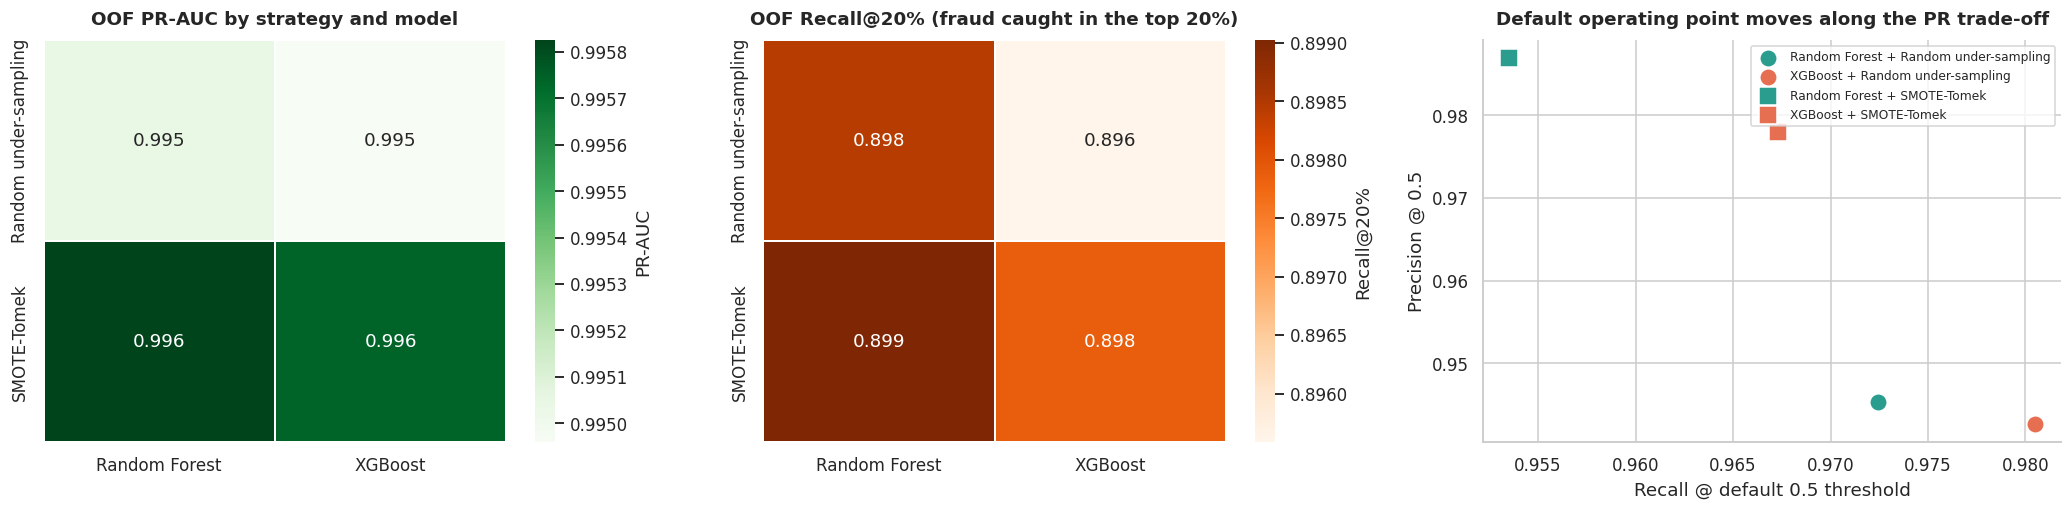

Random Forest  Random under-sampling 0.995 | SMOTE-Tomek 0.996 → better: SMOTE-Tomek (Δ = 0.001)
XGBoost        Random under-sampling 0.995 | SMOTE-Tomek 0.996 → better: SMOTE-Tomek (Δ = 0.001)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
heat = sampling_results.pivot(index="strategy", columns="model", values="PR-AUC").reindex(list(STRATEGIES))[FAMILIES]
sns.heatmap(heat, annot=True, fmt=".3f", cmap="Greens", ax=axes[0], linewidths=1, cbar_kws={"label": "PR-AUC"})
axes[0].set_title("OOF PR-AUC by strategy and model"); axes[0].set_ylabel(""); axes[0].set_xlabel("")

heat2 = sampling_results.pivot(index="strategy", columns="model", values=K).reindex(list(STRATEGIES))[FAMILIES]
sns.heatmap(heat2, annot=True, fmt=".3f", cmap="Oranges", ax=axes[1], linewidths=1, cbar_kws={"label": K})
axes[1].set_title(f"OOF {K} (fraud caught in the top {CFG.alert_budget:.0%})"); axes[1].set_ylabel(""); axes[1].set_xlabel("")

markers = {"Random under-sampling": "o", "SMOTE-Tomek": "s"}
for _, r in sampling_results.iterrows():
    axes[2].scatter(r["Recall@0.5"], r["Precision@0.5"], s=130, marker=markers[r["strategy"]],
                    color=MODEL_COLOR[r["model"]], edgecolor="white", label=f"{r['model']} + {r['strategy']}")
axes[2].set_xlabel("Recall @ default 0.5 threshold"); axes[2].set_ylabel("Precision @ 0.5")
axes[2].set_title("Default operating point moves along the PR trade-off"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

for fam in FAMILIES:
    sub = sampling_results[sampling_results.model == fam].set_index("strategy")["PR-AUC"]
    s_a, s_b = list(STRATEGIES)
    print(f"{fam:<14} {s_a} {sub[s_a]:.3f} | {s_b} {sub[s_b]:.3f} → better: {sub.idxmax()} (Δ = {abs(sub[s_a] - sub[s_b]):.3f})")

**Visualising what the two strategies do.** Training-set class counts after each strategy, and a 2-D PCA projection of the preprocessed training data showing where SMOTE-Tomek places synthetic frauds relative to real ones.

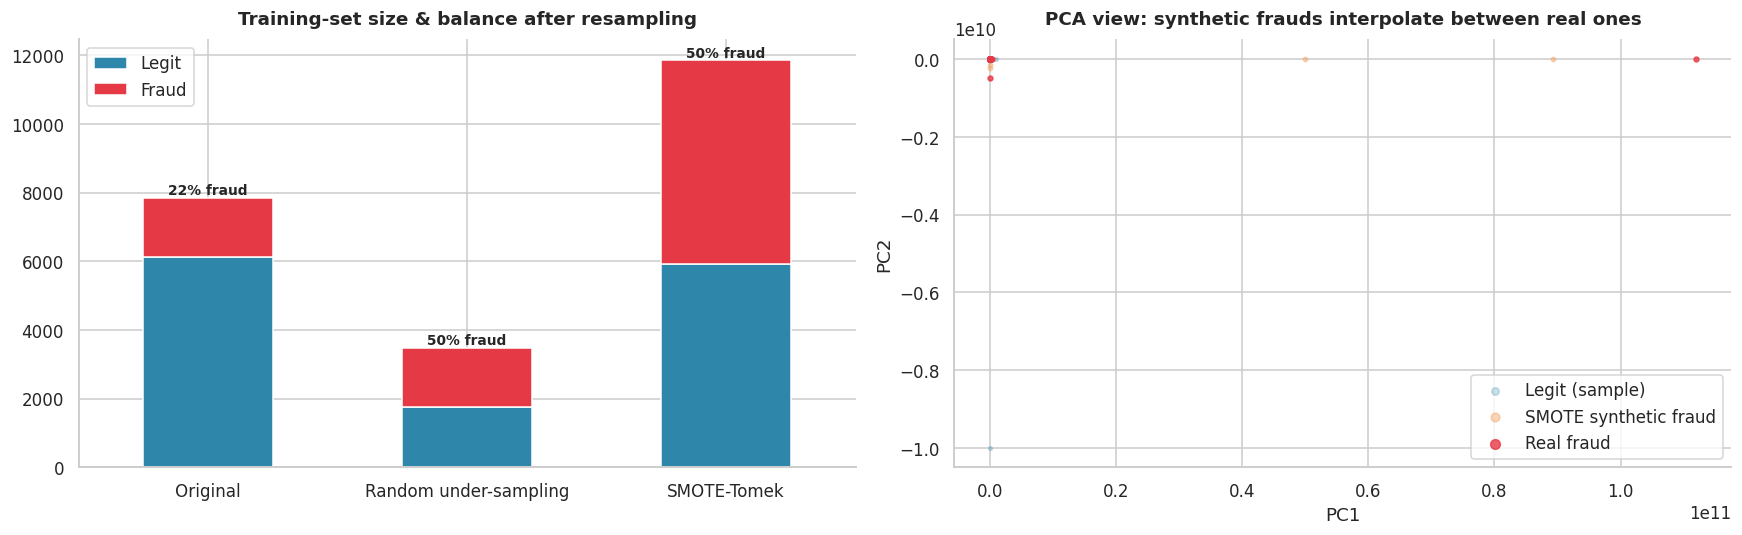

In [16]:
from sklearn.decomposition import PCA
prep_vis = make_preprocessor().fit(X_train)
Xt_vis = prep_vis.transform(X_train)
counts = {"Original": np.bincount(y_train)}
resampled = {}
for name, s in STRATEGIES.items():
    Xr, yr = clone(s).fit_resample(Xt_vis, y_train)
    counts[name] = np.bincount(yr); resampled[name] = (Xr, yr)
counts = pd.DataFrame(counts, index=["Legit", "Fraud"]).T

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
counts.plot(kind="bar", stacked=True, color=[PALETTE["legit"], PALETTE["fraud"]], ax=axes[0], edgecolor="white")
axes[0].set_title("Training-set size & balance after resampling"); axes[0].tick_params(axis="x", rotation=0)
for i, (l, f) in enumerate(counts.values):
    axes[0].text(i, l + f, f"{f/(l+f):.0%} fraud", ha="center", va="bottom", fontsize=9, fontweight="bold")

Xs, ys = resampled["SMOTE-Tomek"]
pca = PCA(n_components=2, random_state=SEED).fit(Xt_vis)
real_legit = pca.transform(Xt_vis[y_train.values == 0]); real_fraud = pca.transform(Xt_vis[y_train.values == 1])
# SMOTE-Tomek may remove rows, so identify synthetic points as those not present among the originals
orig = {tuple(np.round(r, 6)) for r in Xt_vis[y_train.values == 1]}
mask_syn = np.array([(y == 1) and (tuple(np.round(r, 6)) not in orig) for r, y in zip(Xs, ys)])
synthetic = pca.transform(Xs[mask_syn]) if mask_syn.any() else np.empty((0, 2))
rng = np.random.default_rng(SEED)
sl = rng.choice(len(real_legit), min(2500, len(real_legit)), replace=False)
axes[1].scatter(*real_legit[sl].T, s=6, alpha=0.25, color=PALETTE["legit"], label="Legit (sample)")
if len(synthetic):
    ss = rng.choice(len(synthetic), min(1500, len(synthetic)), replace=False)
    axes[1].scatter(*synthetic[ss].T, s=8, alpha=0.45, color=PALETTE["accent"], label="SMOTE synthetic fraud")
axes[1].scatter(*real_fraud.T, s=10, alpha=0.8, color=PALETTE["fraud"], label="Real fraud")
axes[1].set_title("PCA view: synthetic frauds interpolate between real ones")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].legend(markerscale=2)
plt.tight_layout(); plt.show()

**Interpretation.** Both strategies move the *default operating point* (recall ↑, precision ↓ at 0.5), but what matters for model selection is ranking quality (PR-AUC) and the share of fraud caught inside the review budget, because the real threshold is set later with the cost model. Under-sampling is cheap but discards most legitimate accounts; SMOTE-Tomek retains every real account and adds synthetic frauds, at the price of longer training and the risk of unrealistic points. The table above shows which remedy actually wins for each model — each model is carried forward with its own best strategy.

<a id="9"></a>
## 9. Model Comparison: Random Forest vs XGBoost
| Model | Why it is in the comparison |
|---|---|
| **Random Forest** | Bagging of deep, decorrelated trees: very robust, little tuning, hard to overfit badly. Averaging independent trees gives stable but sometimes less sharply-ranked scores. |
| **XGBoost** | Boosting: trees are built sequentially, each correcting the previous residuals, with shrinkage and regularisation. Usually stronger ranking on tabular data, but more sensitive to hyper-parameters. |

Each model is paired with the imbalance strategy that gave it the higher OOF PR-AUC in Section 8, then compared on out-of-fold metrics and fold-by-fold.

Selected configuration: {'Random Forest': 'SMOTE-Tomek', 'XGBoost': 'SMOTE-Tomek'}


,OOF PR-AUC,fold PR-AUC std,OOF ROC-AUC,OOF Recall@20%
model,,,,
Random Forest [SMOTE-Tomek],0.996,0.001,0.999,0.899
XGBoost [SMOTE-Tomek],0.996,0.002,0.998,0.898


,Random Forest [SMOTE-Tomek],XGBoost [SMOTE-Tomek]
fold 1,0.996,0.996
fold 2,0.993,0.993
fold 3,0.996,0.996
fold 4,0.997,0.997
fold 5,0.997,0.998


XGBoost beats Random Forest in 2 of 5 folds (PR-AUC).


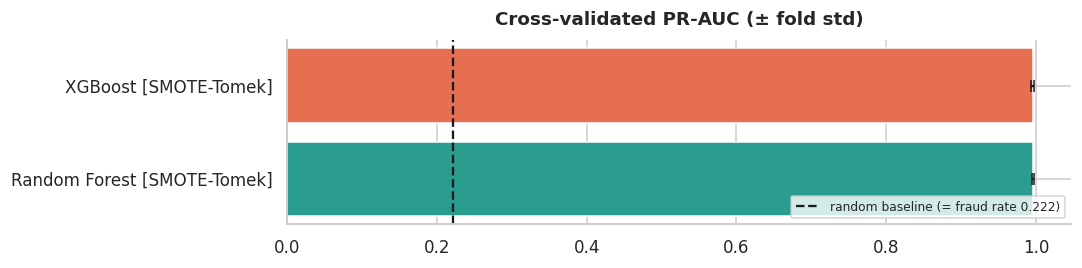

In [17]:
BEST_STRATEGY = {fam: max(STRATEGIES, key=lambda s: sampling_results.query("model == @fam and strategy == @s")["PR-AUC"].iloc[0])
                 for fam in FAMILIES}
MODEL_KEY = {fam: f"{fam} [{BEST_STRATEGY[fam]}]" for fam in FAMILIES}
FINAL_PIPES = {MODEL_KEY[fam]: make_pipeline(fam, BEST_STRATEGY[fam]) for fam in FAMILIES}
FINAL_OOF = {MODEL_KEY[fam]: OOF_PREDS[(fam, BEST_STRATEGY[fam])] for fam in FAMILIES}
print("Selected configuration:", {f: BEST_STRATEGY[f] for f in FAMILIES})

rows = sampling_results.set_index(["model", "strategy"])
cv_table = pd.DataFrame([{"model": MODEL_KEY[f], "OOF PR-AUC": rows.loc[(f, BEST_STRATEGY[f]), "PR-AUC"],
                          "fold PR-AUC std": rows.loc[(f, BEST_STRATEGY[f]), "PR-AUC fold std"],
                          "OOF ROC-AUC": rows.loc[(f, BEST_STRATEGY[f]), "ROC-AUC"],
                          f"OOF {K}": rows.loc[(f, BEST_STRATEGY[f]), K]} for f in FAMILIES]).set_index("model")
display(cv_table.style.background_gradient(subset=["OOF PR-AUC", "OOF ROC-AUC", f"OOF {K}"], cmap="Greens").format("{:.3f}"))

fold_ap = pd.DataFrame({m: [average_precision_score(y_train.iloc[va], FINAL_OOF[m][va]) for _, va in FOLDS] for m in FINAL_OOF},
                       index=[f"fold {i+1}" for i in range(len(FOLDS))])
wins = (fold_ap[MODEL_KEY["XGBoost"]] > fold_ap[MODEL_KEY["Random Forest"]]).sum()
display(fold_ap.style.format("{:.3f}").highlight_max(axis=1, color="#c7e9c0"))
print(f"XGBoost beats Random Forest in {wins} of {len(FOLDS)} folds (PR-AUC).")

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.barh(cv_table.index, cv_table["OOF PR-AUC"], xerr=cv_table["fold PR-AUC std"], capsize=4,
        color=[MODEL_COLOR[f] for f in FAMILIES])
ax.axvline(y_train.mean(), ls="--", color="k", label=f"random baseline (= fraud rate {y_train.mean():.3f})")
ax.set_title("Cross-validated PR-AUC (± fold std)"); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

<a id="10"></a>
## 10. Holdout Evaluation & Business Decisioning
Both models are refit on the full training set and scored **once** on the holdout.

**Threshold policy (no peeking at the test set):** the threshold that minimises expected cost on each model's **out-of-fold** predictions.

**Champion selection** uses OOF PR-AUC (not holdout PR-AUC) so the holdout remains an honest estimate.

In [18]:
FITTED, TEST_PREDS, THRESHOLDS = {}, {}, {}
for name, pipe in FINAL_PIPES.items():
    FITTED[name] = clone(pipe).fit(X_train, y_train)
    TEST_PREDS[name] = FITTED[name].predict_proba(X_test)[:, 1]
    THRESHOLDS[name] = best_threshold(y_train, FINAL_OOF[name])

holdout = pd.DataFrame([evaluate(y_test, TEST_PREDS[m], THRESHOLDS[m], m) for m in TEST_PREDS]).set_index("model")
fmt = {"alert_rate": "{:.1%}", "savings_vs_no_model": "{:.1%}", "precision": "{:.1%}", "recall": "{:.1%}",
       "exp_cost": "{:,.0f}", "TP": "{:.0f}", "FP": "{:.0f}", "FN": "{:.0f}", "threshold": "{:.4f}"}
display(pd.DataFrame({m: {k: fmt.get(k, "{:.3f}").format(v) for k, v in row.items()} for m, row in holdout.iterrows()}))

CHAMPION = max(FINAL_OOF, key=lambda n: average_precision_score(y_train, FINAL_OOF[n]))
champ_thr, p_champ = THRESHOLDS[CHAMPION], TEST_PREDS[CHAMPION]
display(Markdown(f"###Champion (selected on OOF PR-AUC): **{CHAMPION}**  \n"
                 f"Holdout PR-AUC **{holdout.loc[CHAMPION, 'PR-AUC']:.3f}** (random = {y_test.mean():.3f}), "
                 f"ROC-AUC **{holdout.loc[CHAMPION, 'ROC-AUC']:.3f}**, catches **{holdout.loc[CHAMPION, K]:.1%}** "
                 f"of fraud in the top {CFG.alert_budget:.0%} of accounts, and cuts expected cost by "
                 f"**{holdout.loc[CHAMPION, 'savings_vs_no_model']:.1%}** vs. no model."))

,Random Forest [SMOTE-Tomek],XGBoost [SMOTE-Tomek]
PR-AUC,0.994,0.995
ROC-AUC,0.998,0.998
Recall@20%,0.899,0.901
threshold,0.2121,0.0197
precision,88.5%,87.2%
recall,97.5%,98.4%
F2,0.955,0.959
alert_rate,24.4%,25.1%
TP,425,429
FP,55,63


### 🏆 Champion (selected on OOF PR-AUC): **Random Forest [SMOTE-Tomek]**  
Holdout PR-AUC **0.994** (random = 0.222), ROC-AUC **0.998**, catches **89.9%** of fraud in the top 20% of accounts, and cuts expected cost by **96.8%** vs. no model.

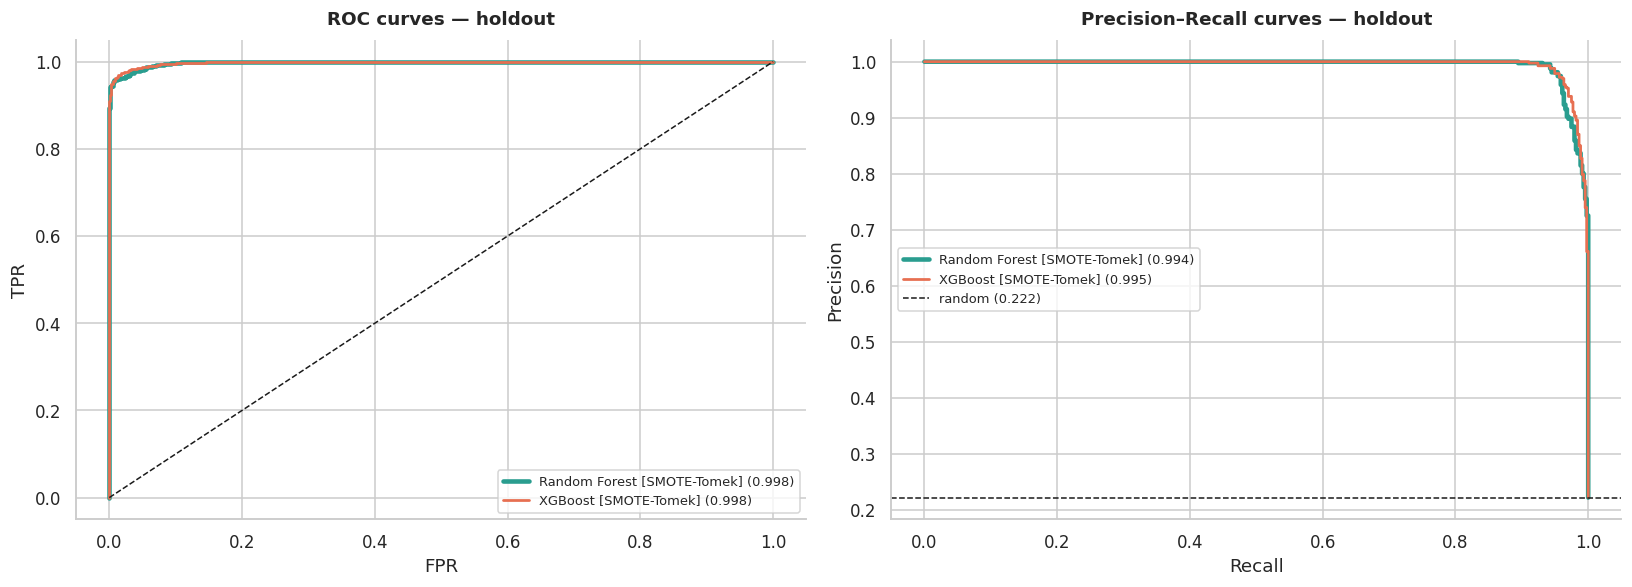

In [19]:
color_of = {MODEL_KEY[f]: MODEL_COLOR[f] for f in FAMILIES}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for m in TEST_PREDS:
    lw = 3 if m == CHAMPION else 1.8
    fpr, tpr, _ = roc_curve(y_test, TEST_PREDS[m]); prec, rec, _ = precision_recall_curve(y_test, TEST_PREDS[m])
    axes[0].plot(fpr, tpr, lw=lw, color=color_of[m], label=f"{m} ({holdout.loc[m, 'ROC-AUC']:.3f})")
    axes[1].plot(rec, prec, lw=lw, color=color_of[m], label=f"{m} ({holdout.loc[m, 'PR-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1); axes[0].set_title("ROC curves — holdout"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[1].axhline(y_test.mean(), ls="--", color="k", lw=1, label=f"random ({y_test.mean():.3f})")
axes[1].set_title("Precision–Recall curves — holdout"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
for ax in axes: ax.legend(fontsize=8.5, loc="best")
plt.tight_layout(); plt.show()

### 10.1 Is the gap real? Paired bootstrap on the holdout
Both models score the **same** resampled accounts in each bootstrap draw, so the PR-AUC difference isolates model quality from sampling luck.

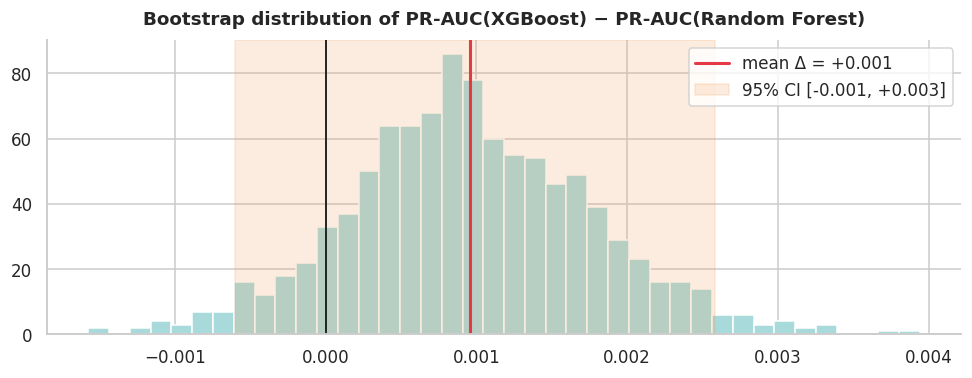

P(XGBoost > Random Forest) = 89.3% → the two models are NOT statistically distinguishable (CI includes 0) on this holdout.


In [20]:
rf_key, xg_key = MODEL_KEY["Random Forest"], MODEL_KEY["XGBoost"]
yv, rng, diffs = y_test.values, np.random.default_rng(SEED), []
for _ in range(CFG.n_bootstrap):
    idx = rng.integers(0, len(yv), len(yv))
    if yv[idx].sum() == 0: continue
    diffs.append(average_precision_score(yv[idx], TEST_PREDS[xg_key][idx]) - average_precision_score(yv[idx], TEST_PREDS[rf_key][idx]))
diffs = np.array(diffs); lo, hi = np.percentile(diffs, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(diffs, bins=40, color=PALETTE["muted"], edgecolor="white")
ax.axvline(0, color="k", lw=1.2); ax.axvline(diffs.mean(), color=PALETTE["fraud"], lw=2, label=f"mean Δ = {diffs.mean():+.3f}")
ax.axvspan(lo, hi, color=PALETTE["accent"], alpha=0.2, label=f"95% CI [{lo:+.3f}, {hi:+.3f}]")
ax.set_title("Bootstrap distribution of PR-AUC(XGBoost) − PR-AUC(Random Forest)"); ax.legend()
plt.tight_layout(); plt.show()
verdict = "statistically distinguishable" if (lo > 0 or hi < 0) else "NOT statistically distinguishable (CI includes 0)"
print(f"P(XGBoost > Random Forest) = {(diffs > 0).mean():.1%} → the two models are {verdict} on this holdout.")

### 10.2 Operating point, gains & calibration
Confusion matrices at each model's cost-optimal threshold, the cumulative-gains view of review capacity, and reliability diagrams.

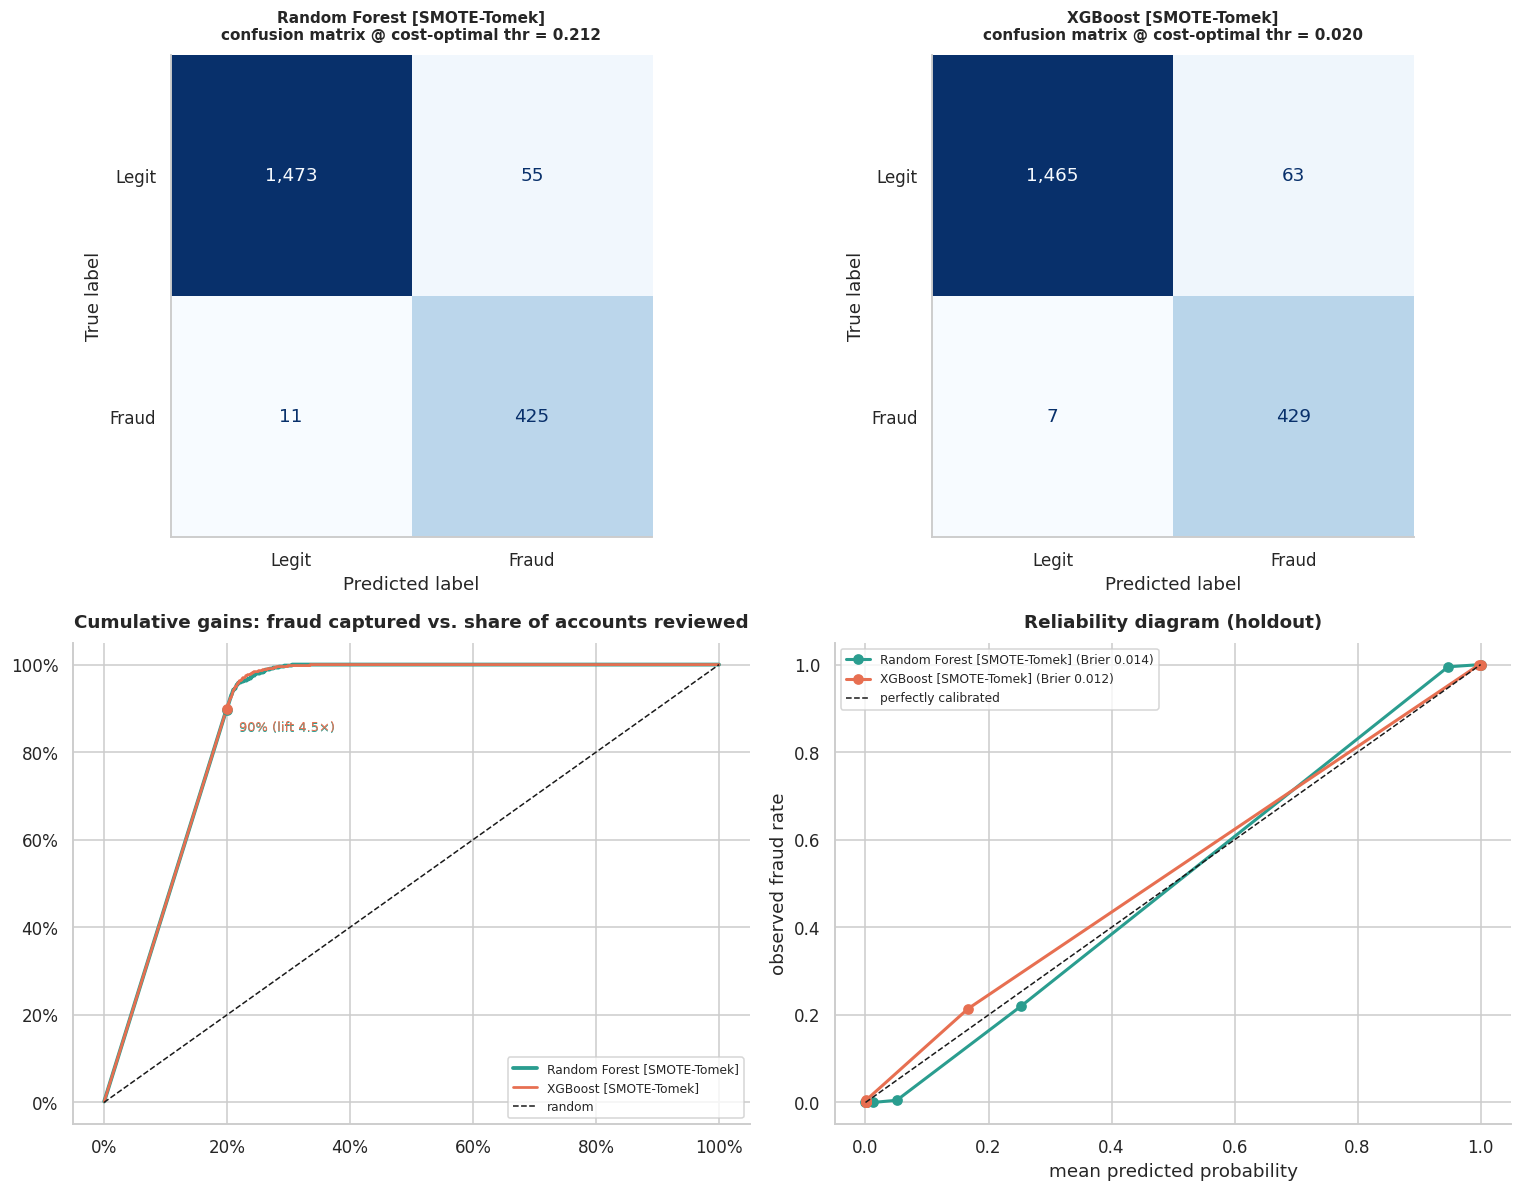

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, m in zip(axes[0], TEST_PREDS):
    cm = confusion_matrix(y_test, (TEST_PREDS[m] >= THRESHOLDS[m]).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format=",")
    ax.set_title(f"{m}\nconfusion matrix @ cost-optimal thr = {THRESHOLDS[m]:.3f}", fontsize=10); ax.grid(False)

ax = axes[1, 0]
for m in TEST_PREDS:
    order = np.argsort(-TEST_PREDS[m]); y_sorted = y_test.values[order]
    pct_inv = np.arange(1, len(y_sorted) + 1) / len(y_sorted); gains = np.cumsum(y_sorted) / y_sorted.sum()
    ax.plot(pct_inv, gains, color=color_of[m], lw=2.5 if m == CHAMPION else 1.8, label=m)
    g_k = gains[int(CFG.alert_budget * len(gains)) - 1]
    ax.scatter(CFG.alert_budget, g_k, color=color_of[m], zorder=5)
    ax.annotate(f"{g_k:.0%} (lift {g_k/CFG.alert_budget:.1f}×)", (CFG.alert_budget, g_k), xytext=(8, -14), textcoords="offset points", fontsize=8.5, color=color_of[m])
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_title("Cumulative gains: fraud captured vs. share of accounts reviewed")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend(loc="lower right", fontsize=8)

ax = axes[1, 1]
for m in TEST_PREDS:
    pt, pp = calibration_curve(y_test, TEST_PREDS[m], n_bins=10, strategy="quantile")
    ax.plot(pp, pt, marker="o", color=color_of[m], lw=2, label=f"{m} (Brier {brier_score_loss(y_test, TEST_PREDS[m]):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
ax.set_title("Reliability diagram (holdout)"); ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed fraud rate"); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

**Reading the calibration plot.** Both resampling strategies deliberately shift the class balance seen in training, so predicted probabilities no longer match real fraud frequencies (curves usually sit *above or below* the diagonal). That is harmless for ranking and for the explicit cost-optimal threshold. If downstream systems need true probabilities, wrap the chosen model in `CalibratedClassifierCV(method="isotonic")`.

### 10.3 What does each model rely on? Permutation importance
Shuffling one feature at a time on the **holdout** and measuring the drop in PR-AUC shows how much each model genuinely depends on it — a model-agnostic view that is comparable across Random Forest and XGBoost.

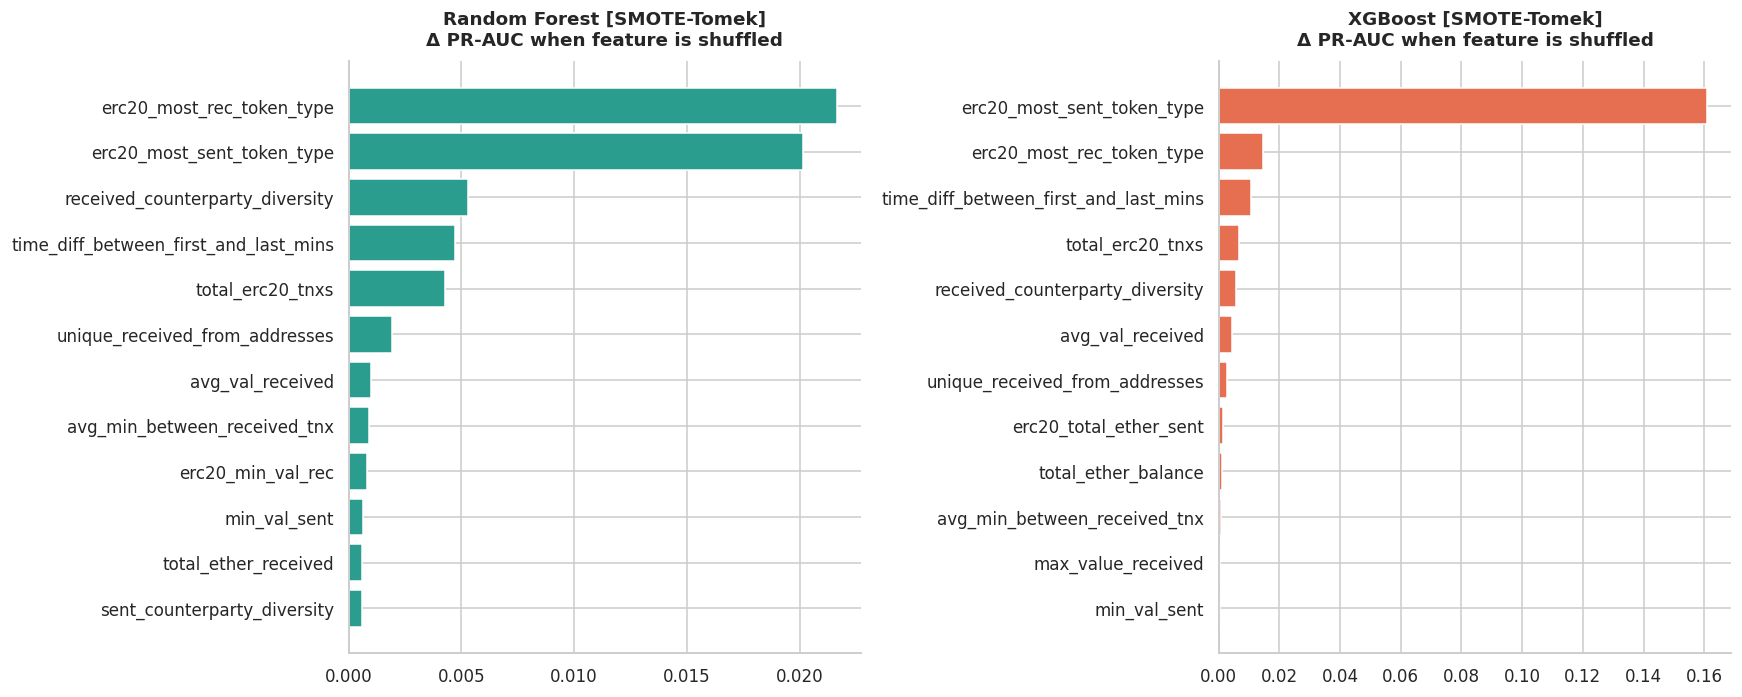

Overlap in the top-10 most important features: 8 → ['avg_min_between_received_tnx', 'avg_val_received', 'erc20_most_rec_token_type', 'erc20_most_sent_token_type', 'received_counterparty_diversity', 'time_diff_between_first_and_last_mins', 'total_erc20_tnxs', 'unique_received_from_addresses']


,Random Forest,XGBoost
erc20_most_sent_token_type,0.0201,0.1609
erc20_most_rec_token_type,0.0217,0.0147
time_diff_between_first_and_last_mins,0.0047,0.0108
received_counterparty_diversity,0.0053,0.0056
total_erc20_tnxs,0.0043,0.0066
avg_val_received,0.0010,0.0043
unique_received_from_addresses,0.0019,0.0029
erc20_total_ether_sent,0.0004,0.0015
avg_min_between_received_tnx,0.0009,0.0009
total_ether_balance,0.0004,0.0011


In [23]:
perm = {}
for m, est in FITTED.items():
    r = permutation_importance(est, X_test, y_test, scoring="average_precision", n_repeats=CFG.n_perm_repeats,
                               random_state=SEED, n_jobs=1)
    perm[m] = pd.Series(r.importances_mean, index=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, m in zip(axes, perm):
    top = perm[m].sort_values(ascending=False).head(12).sort_values()
    ax.barh(top.index, top.values, color=color_of[m]); ax.set_title(f"{m}\nΔ PR-AUC when feature is shuffled")
plt.tight_layout(); plt.show()

both = pd.DataFrame(perm).rename(columns={rf_key: "Random Forest", xg_key: "XGBoost"})
overlap = set(both["Random Forest"].nlargest(10).index) & set(both["XGBoost"].nlargest(10).index)
print(f"Overlap in the top-10 most important features: {len(overlap)} → {sorted(overlap)}")
display(both.assign(avg=both.mean(axis=1)).sort_values("avg", ascending=False).drop(columns="avg").head(10).style.format("{:.4f}"))

<a id="11"></a>
## 11. Conclusions

In [24]:
a, b = holdout.loc[rf_key], holdout.loc[xg_key]
summary = f"""
| Question | Random Forest | XGBoost |
|---|---|---|
| Imbalance strategy selected (CV) | {BEST_STRATEGY['Random Forest']} | {BEST_STRATEGY['XGBoost']} |
| OOF PR-AUC (train CV) | {cv_table.loc[rf_key, 'OOF PR-AUC']:.3f} | {cv_table.loc[xg_key, 'OOF PR-AUC']:.3f} |
| Holdout PR-AUC (random = {y_test.mean():.3f}) | {a['PR-AUC']:.3f} | {b['PR-AUC']:.3f} |
| Holdout ROC-AUC | {a['ROC-AUC']:.3f} | {b['ROC-AUC']:.3f} |
| Fraud caught in top {CFG.alert_budget:.0%} of accounts | {a[K]:.1%} | {b[K]:.1%} |
| Cost-optimal policy: alert rate / recall / precision | {a['alert_rate']:.1%} / {a['recall']:.1%} / {a['precision']:.1%} | {b['alert_rate']:.1%} / {b['recall']:.1%} / {b['precision']:.1%} |
| Expected-cost saving vs no model (illustrative costs) | {a['savings_vs_no_model']:.1%} | {b['savings_vs_no_model']:.1%} |

**Champion (by OOF PR-AUC): {CHAMPION}.** Paired-bootstrap PR-AUC gap (XGBoost − Random Forest): {diffs.mean():+.3f}, 95% CI [{lo:+.3f}, {hi:+.3f}] → {verdict}.
"""
display(Markdown(summary))


| Question | Random Forest | XGBoost |
|---|---|---|
| Imbalance strategy selected (CV) | SMOTE-Tomek | SMOTE-Tomek |
| OOF PR-AUC (train CV) | 0.996 | 0.996 |
| Holdout PR-AUC (random = 0.222) | 0.994 | 0.995 |
| Holdout ROC-AUC | 0.998 | 0.998 |
| Fraud caught in top 20% of accounts | 89.9% | 90.1% |
| Cost-optimal policy: alert rate / recall / precision | 24.4% / 97.5% / 88.5% | 25.1% / 98.4% / 87.2% |
| Expected-cost saving vs no model (illustrative costs) | 96.8% | 97.7% |

**Champion (by OOF PR-AUC): Random Forest [SMOTE-Tomek].** Paired-bootstrap PR-AUC gap (XGBoost − Random Forest): +0.001, 95% CI [-0.001, +0.003] → NOT statistically distinguishable (CI includes 0).


### Key lessons
1. **Metric choice is a design decision.** Accuracy rewards predicting "legit" for everyone; PR-AUC, recall-at-budget and expected cost tell the business story.
2. **Handle imbalance inside the pipeline.** Resampling outside CV leaks synthetic copies of validation frauds into training and inflates scores; here both strategies only ever see the training fold.
3. **The best imbalance remedy is model-specific.** Under-sampling and SMOTE-Tomek were compared per model rather than assumed, and each model was carried forward with its own winner.
4. **Judge the model gap with uncertainty.** A paired bootstrap shows whether the difference between the two models exceeds sampling noise on a holdout of limited size.
5. **Behaviour beats size.** Permutation importance shows which behavioural signals both models agree on — agreement across very different ensembles is stronger evidence than either ranking alone.
6. **The threshold is where ML meets the business.** Ranking quality comes from the model; the operating point comes from costs and review capacity (the costs used here are illustrative placeholders).

### Limitations & next steps
- The data is a static account-level snapshot with no timestamps, so out-of-time validation is impossible; real deployment needs rolling re-validation as scam tactics evolve.
- Labels reflect *known* fraudulent accounts; undetected fraud is labelled legitimate, which biases every estimate.
- Natural extensions (deliberately out of scope here): hyper-parameter tuning, additional models, SHAP explanations and transaction-graph features.